# Лабораторная работа 3
## Часть 2. Линейная регрессия (парная и множественная)

**Датасеты:**

- `Salary Data.csv` — парная регрессия (зависимость зарплаты от стажа)
- `CarPrice_Assignment.csv` — множественная регрессия (предсказание цены автомобиля)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## 1. Модель парной линейной регрессии

Датасет `Salary Data.csv`: признак — стаж работы (`YearsExperience`), цель — зарплата (`Salary`).

### Визуальный аудит данных

In [38]:
salary = pd.read_csv("../part1/datasets/Salary Data.csv")

print("Размер датасета:", salary.shape)
salary.head()

Размер датасета: (30, 2)


,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [8]:
salary.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [9]:
print("Пропуски по столбцам:")
print(salary.isna().sum())
print("\nДубликатов строк:", salary.duplicated().sum())

Пропуски по столбцам:
YearsExperience    0
Salary             0
dtype: int64

Дубликатов строк: 0


In [10]:
salary.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


### Выделение X и y, разделение на train/test (80/20)


In [14]:
from sklearn.model_selection import train_test_split

X_s = salary[["YearsExperience"]]
y_s = salary["Salary"]

test_size = 0.2
random_state = 67

X_s_train, X_s_test, y_s_train, y_s_test = train_test_split(X_s, y_s, test_size=test_size, random_state=random_state)

print("Train:", X_s_train.shape, "| Test:", X_s_test.shape)

Train: (24, 1) | Test: (6, 1)


### Обучение модели и параметры

In [15]:
from sklearn.linear_model import LinearRegression

model_simple = LinearRegression()
model_simple.fit(X_s_train, y_s_train)

slope = model_simple.coef_[0]
intercept = model_simple.intercept_

print(f"Коэффициент наклона (slope):  {slope:.2f}")
print(f"Свободный член (intercept):   {intercept:.2f}")
print(f"\nУравнение: Salary = {slope:.2f} * YearsExperience + {intercept:.2f}")

Коэффициент наклона (slope):  9401.04
Свободный член (intercept):   26155.22

Уравнение: Salary = 9401.04 * YearsExperience + 26155.22


### График регрессии

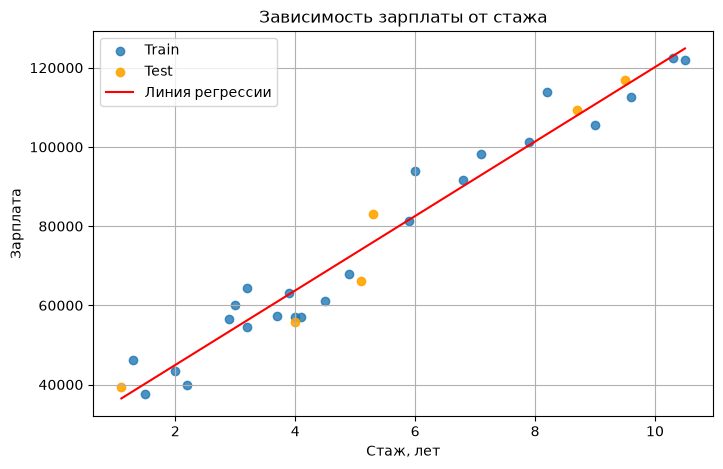

In [16]:
x_line = np.linspace(X_s["YearsExperience"].min(), X_s["YearsExperience"].max(), 100)
y_line = model_simple.predict(pd.DataFrame({"YearsExperience": x_line}))

plt.figure(figsize=(8, 5))
plt.scatter(X_s_train, y_s_train, label="Train", alpha=0.8)
plt.scatter(X_s_test, y_s_test, label="Test", color="orange", alpha=0.9)
plt.plot(x_line, y_line, color="red", label="Линия регрессии")

plt.title("Зависимость зарплаты от стажа")
plt.xlabel("Стаж, лет")
plt.ylabel("Зарплата")
plt.legend()
plt.grid(True)
plt.show()

## 2. Модель множественной линейной регрессии

Датасет `CarPrice_Assignment.csv`: цель — цена автомобиля (`price`), признаки — числовые характеристики автомобиля.

### Визуальный аудит данных

In [18]:
cars = pd.read_csv("../part1/datasets/CarPrice_Assignment.csv")

print("Размер датасета:", cars.shape)
cars.head()

Размер датасета: (205, 26)


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [19]:
cars.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    str    
 3   fueltype          205 non-null    str    
 4   aspiration        205 non-null    str    
 5   doornumber        205 non-null    str    
 6   carbody           205 non-null    str    
 7   drivewheel        205 non-null    str    
 8   enginelocation    205 non-null    str    
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    str    
 15  cylindernumber    205 non-null    str    
 16  enginesize        205 non-null    int64  
 17  fuelsyst

In [20]:
print("Всего пропусков:", cars.isna().sum().sum())
print("Дубликатов строк:", cars.duplicated().sum())

Всего пропусков: 0
Дубликатов строк: 0


### Выбор числовых признаков

`car_ID` — просто идентификатор строки, поэтому он не используется. Категориальные признаки (марка, тип кузова и т.д.) в данной работе не рассматриваются — для линейной регрессии их нужно кодировать отдельно.

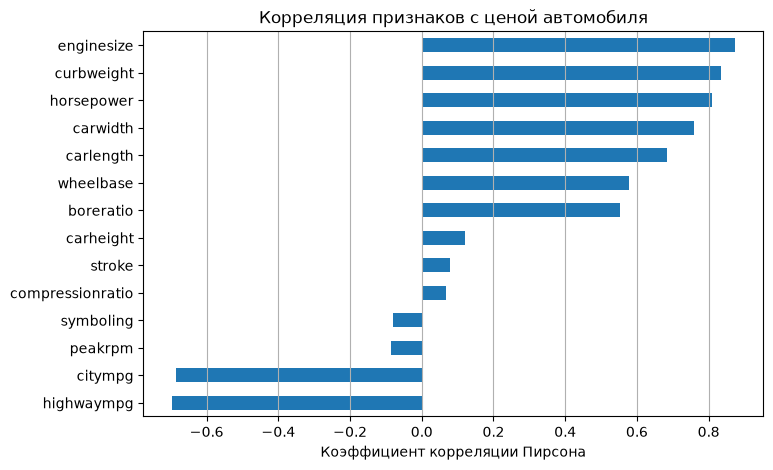

enginesize    0.874145
curbweight    0.835305
horsepower    0.808139
carwidth      0.759325
carlength     0.682920
Name: price, dtype: float64

In [22]:
numeric_features = [
    "symboling", "wheelbase", "carlength", "carwidth", "carheight",
    "curbweight", "enginesize", "boreratio", "stroke",
    "compressionratio", "horsepower", "peakrpm", "citympg", "highwaympg",
]
TARGET = "price"

corr = cars[numeric_features + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

plt.figure(figsize=(8, 5))
corr.plot(kind="barh")
plt.title("Корреляция признаков с ценой автомобиля")
plt.xlabel("Коэффициент корреляции Пирсона")
plt.grid(True, axis="x")
plt.show()

corr.sort_values(ascending=False).head(5)

По корреляции самые сильные признаки — `enginesize`, `curbweight` и `horsepower`. Они будут использоваться в экспериментах.

### Разделение выборки

Все три эксперимента используют **одно и то же** разбиение (одни и те же строки в train/test), чтобы метрики были сравнимы.

In [24]:
train_idx, test_idx = train_test_split(
    cars.index, test_size=test_size, random_state=random_state
)

y_train = cars.loc[train_idx, TARGET]
y_test = cars.loc[test_idx, TARGET]

print("Train:", len(train_idx), "| Test:", len(test_idx))


Train: 164 | Test: 41


### Эксперименты с признаками

- **Эксперимент А** — один самый сильный признак: `enginesize`
- **Эксперимент Б** — два признака: `enginesize` + `curbweight`
- **Эксперимент В** — все числовые признаки

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

experiments = {
    "А: enginesize": ["enginesize"],
    "Б: enginesize + curbweight": ["enginesize", "curbweight"],
    "В: все числовые признаки": numeric_features,
}

def evaluate(model, X_test, y_test):
    pred = model.predict(X_test)
    return {
        "MAE": mean_absolute_error(y_test, pred),
        "MSE": mean_squared_error(y_test, pred),
        "R2": r2_score(y_test, pred),
    }

models = {}
results = {}

for name, features in experiments.items():
    model = LinearRegression()
    model.fit(cars.loc[train_idx, features], y_train)
    models[name] = (model, features)
    results[name] = evaluate(model, cars.loc[test_idx, features], y_test)
    print(f"{name}: признаков = {len(features)}, R2 (test) = {results[name]['R2']:.4f}")

А: enginesize: признаков = 1, R2 (test) = 0.8254
Б: enginesize + curbweight: признаков = 2, R2 (test) = 0.8344
В: все числовые признаки: признаков = 14, R2 (test) = 0.8698


### Параметры моделей

In [29]:
for name, (model, features) in models.items():
    print(f"=== Эксперимент {name} ===")
    print(f"Intercept: {model.intercept_:.2f}")
    coefs = pd.Series(model.coef_, index=features)
    print(coefs.round(3).to_string())
    print()

=== Эксперимент А: enginesize ===
Intercept: -6804.58
enginesize    156.917

=== Эксперимент Б: enginesize + curbweight ===
Intercept: -13199.26
enginesize    102.648
curbweight      5.175

=== Эксперимент В: все числовые признаки ===
Intercept: -52972.81
symboling            459.709
wheelbase            225.517
carlength            -79.575
carwidth             490.606
carheight            143.553
curbweight             1.516
enginesize            98.491
boreratio          -1531.769
stroke             -3739.695
compressionratio     304.040
horsepower            45.649
peakrpm                2.170
citympg             -302.428
highwaympg           221.745



## 3. Оценка качества и сравнение моделей

Метрики считаются на **тестовой** выборке.

In [30]:
simple_metrics = evaluate(model_simple, X_s_test, y_s_test)

comparison = pd.DataFrame(
    {
        "Датасет": ["Salary Data"] + ["CarPrice"] * len(results),
        "Модель": ["Парная: YearsExperience"] + [f"Множественная {n}" for n in results],
        "Признаков": [1] + [len(experiments[n]) for n in results],
        "MAE": [simple_metrics["MAE"]] + [r["MAE"] for r in results.values()],
        "MSE": [simple_metrics["MSE"]] + [r["MSE"] for r in results.values()],
        "R2": [simple_metrics["R2"]] + [r["R2"] for r in results.values()],
    }
)

comparison.round(4)

,Датасет,Модель,Признаков,MAE,MSE,R2
0,Salary Data,Парная: YearsExperience,1,4830.2396,3.194757e+07,0.9589
1,CarPrice,Множественная А: enginesize,1,3093.6017,1.769244e+07,0.8254
2,CarPrice,Множественная Б: enginesize + curbweight,2,2714.9925,1.678897e+07,0.8344
3,CarPrice,Множественная В: все числовые признаки,14,2759.5281,1.320052e+07,0.8698


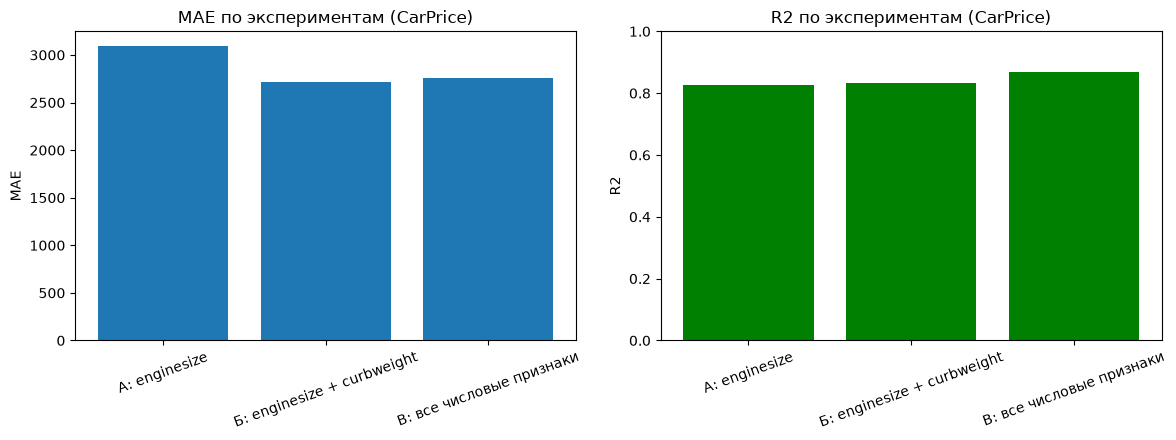

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

car_labels = list(results.keys())
axes[0].bar(car_labels, [results[n]["MAE"] for n in car_labels])
axes[0].set_title("MAE по экспериментам (CarPrice)")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(car_labels, [results[n]["R2"] for n in car_labels], color="green")
axes[1].set_title("R2 по экспериментам (CarPrice)")
axes[1].set_ylabel("R2")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

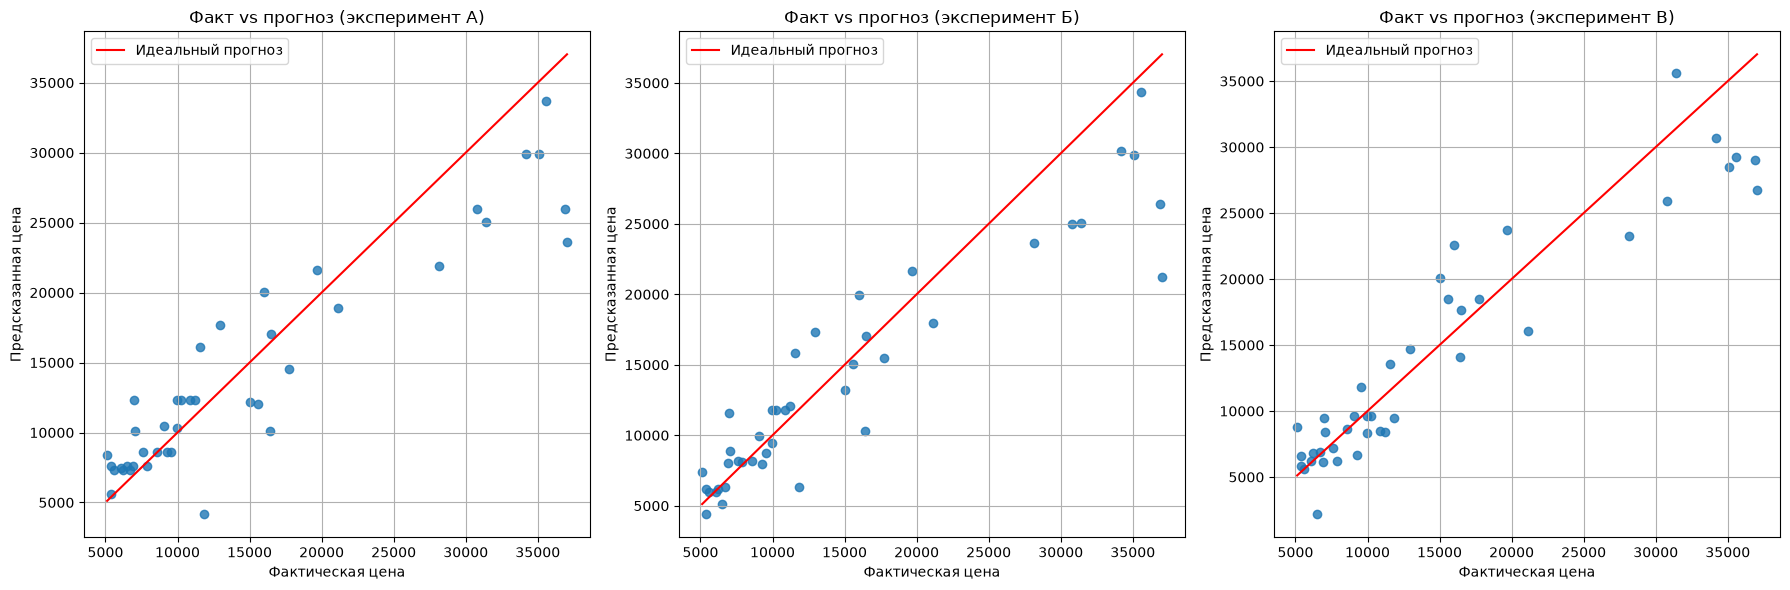

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
lims = [y_test.min(), y_test.max()]

for ax, (name, (model, features)) in zip(axes, models.items()):
    pred = model.predict(cars.loc[test_idx, features])
    
    ax.scatter(y_test, pred, alpha=0.8)
    ax.plot(lims, lims, color="red", label="Идеальный прогноз")
    
    ax.set_title(f"Факт vs прогноз (эксперимент {name[0]})")
    ax.set_xlabel("Фактическая цена")
    ax.set_ylabel("Предсказанная цена")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


## Экспорт моделей для Streamlit-приложения (часть 3)

Сохраняются модели вместе с названиями признаков и диапазонами значений (для ползунков).

In [43]:
import joblib

salary_bundle = {
    "model": model_simple,
    "features": ["YearsExperience"],
    "target": "Salary",
    "ranges": {"YearsExperience": (float(X_s.min().iloc[0]), float(X_s.max().iloc[0]))},
    "data": salary,
    "metrics": simple_metrics,
}
joblib.dump(salary_bundle, "../part3/models/salary_model.joblib")

cars_bundles = {}
for name, (model, features) in models.items():
    cars_bundles[name] = {
        "model": model,
        "features": features,
        "target": TARGET,
        "ranges": {f: (float(cars[f].min()), float(cars[f].max())) for f in features},
        "means": {f: float(cars[f].mean()) for f in features},
        "metrics": results[name],
    }
joblib.dump(cars_bundles, "../part3/models/car_models.joblib")

print("Сохранено")

Сохранено


## Выводы

**Парная регрессия (Salary Data).** Зависимость зарплаты от стажа почти линейна: каждый дополнительный год стажа увеличивает прогноз зарплаты примерно на 9 400, при этом R² на тестовой выборке ≈ 0.90. 

**Множественная регрессия (CarPrice).**

- **Эксперимент А** (`enginesize`): R² ≈ 0.80 — один признак уже объясняет большую часть разброса цен.
- **Эксперимент Б** (`enginesize` + `curbweight`): лучший результат — R² ≈ 0.83, MAE ≈ 2500. Добавление второго сильного признака улучшило качество.
- **Эксперимент В** (все числовые признаки): R² ≈ 0.81 — чуть хуже, чем у Б, несмотря на 14 признаков. Многие признаки сильно коррелируют между собой (мультиколлинеарность: размеры, вес, мощность), поэтому дополнительные признаки почти не несут новой информации и могут добавлять шум (например, отрицательный коэффициент у `carlength` при положительной корреляции с ценой).

